In [ ]:
!nvidia-smi

Tue May 26 12:53:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.9/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nYByYzjVKl7Acn8l90I6")
project = rf.workspace("autodarts-rcubg").project("up_board-dgrii")
version = project.version(1)
dataset = version.download("yolov8")





loading Roboflow workspace...
loading Roboflow project...


In [ ]:
%cd {HOME}

!yolo task=detect \
    mode=train \
    model=yolov8s.pt \
    data={dataset.location}/data.yaml \
    epochs=10 \
    patience=10 \
    imgsz=640 \
    plots=True

/content
New https://pypi.org/project/ultralytics/8.4.54 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/UP_board-1/data.yaml, epochs=10, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=

/content


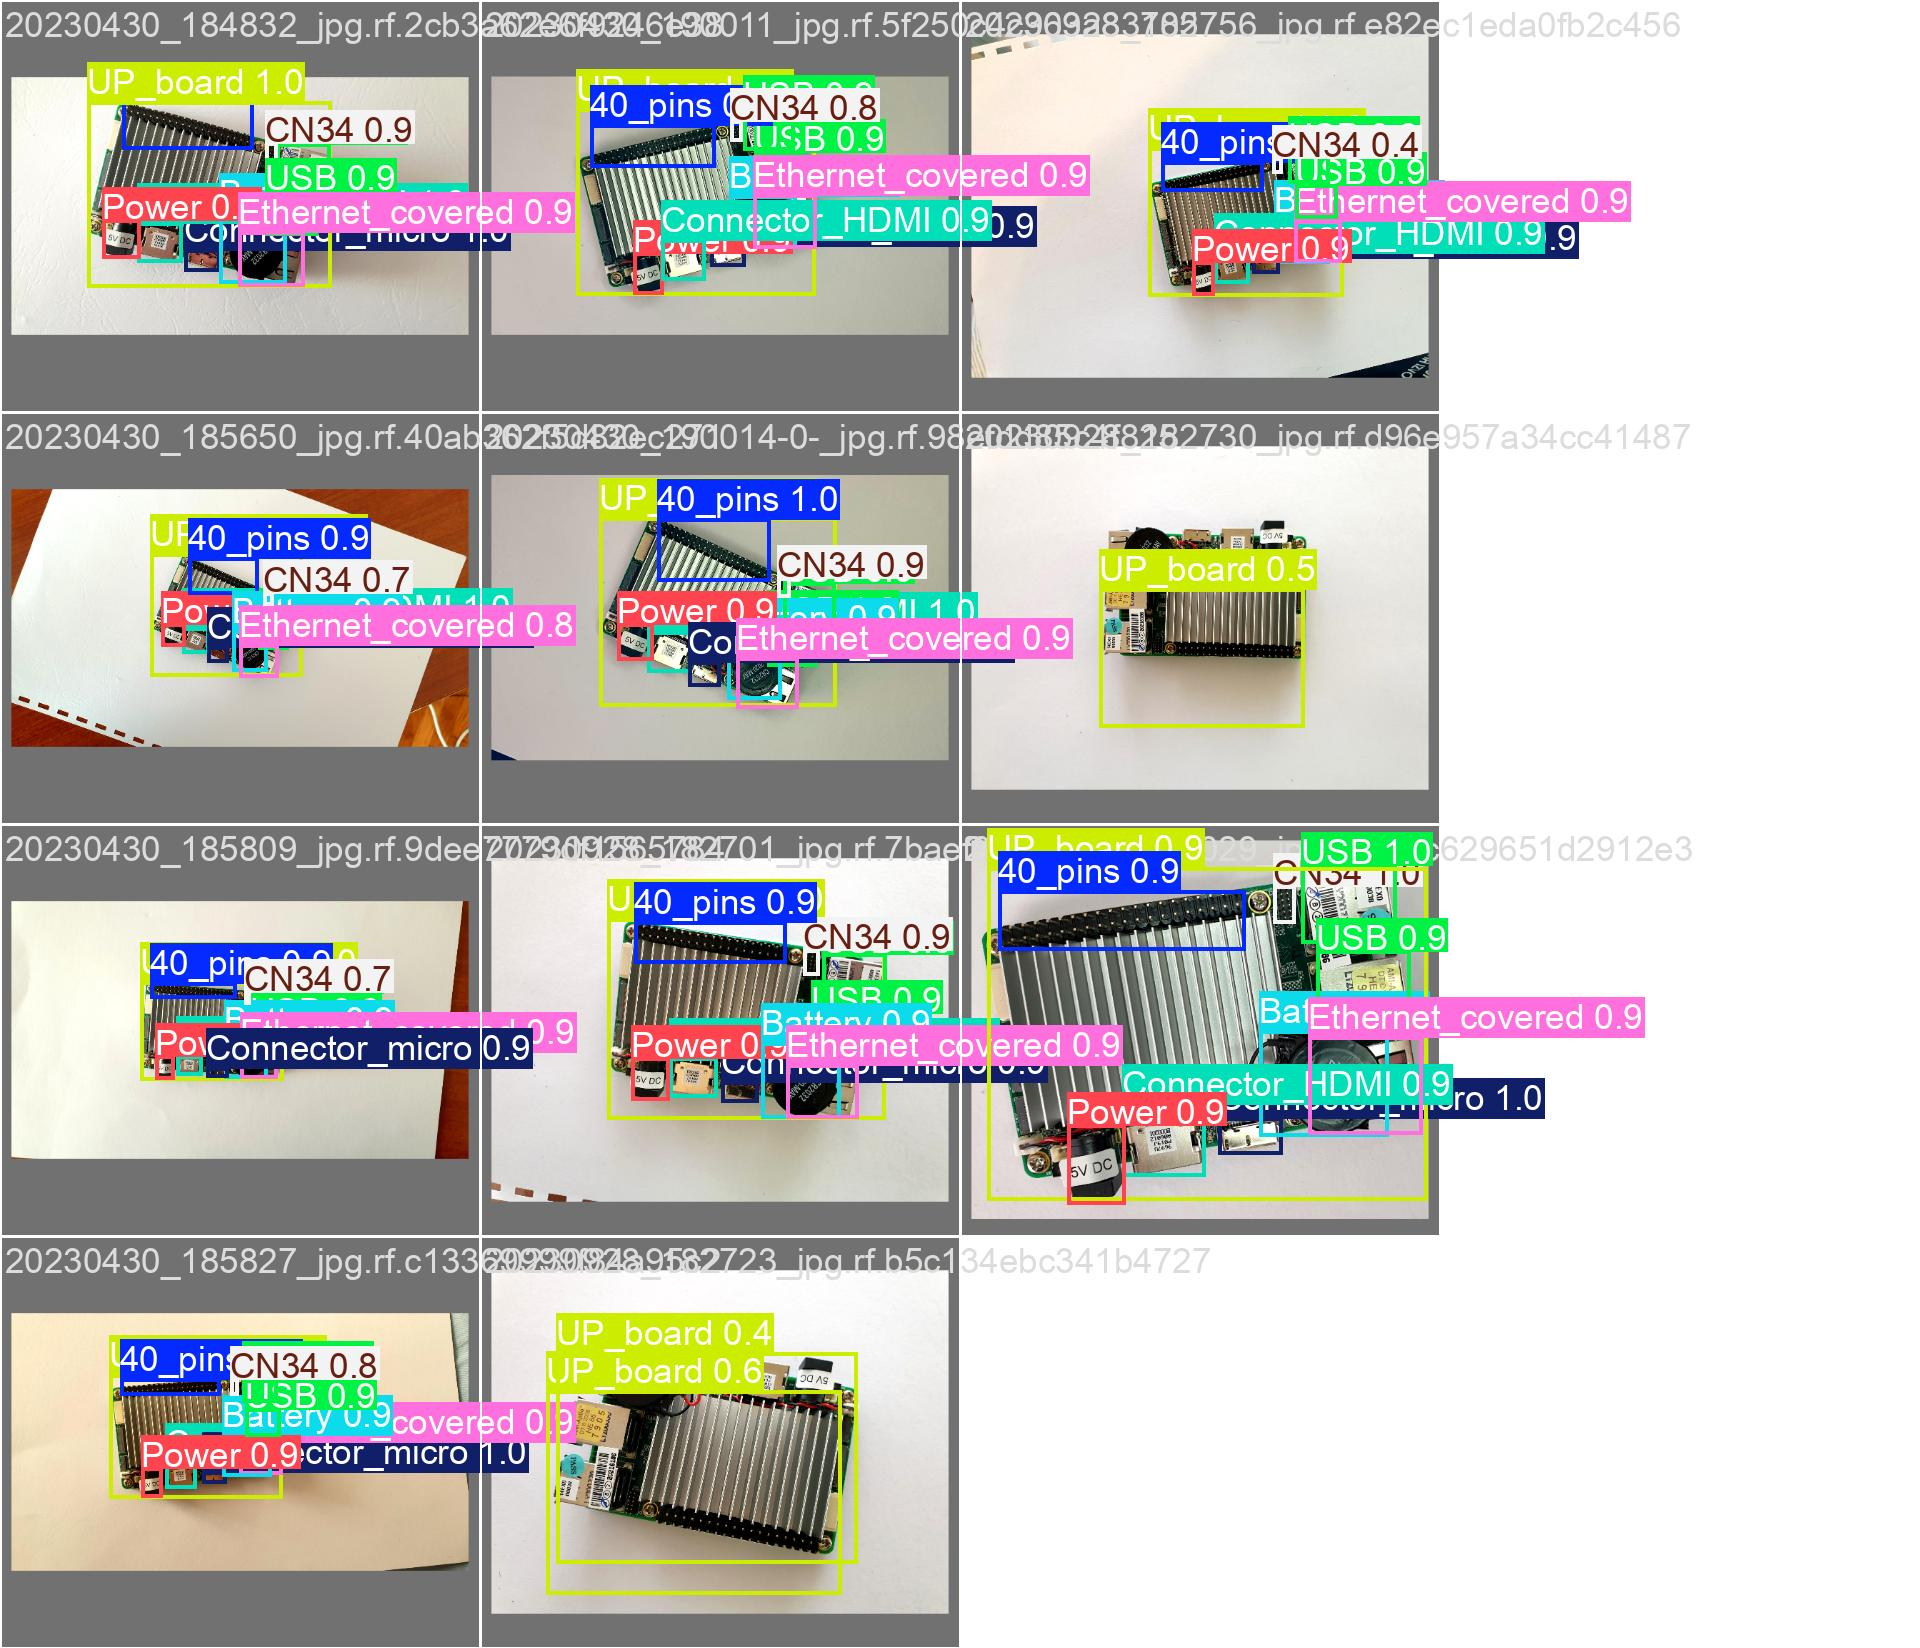

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)

In [ ]:
%cd {HOME}
!yolo task=detect \
  mode=predict \
  model={HOME}/runs/detect/train2/weights/best.pt \
  conf=0.25 \
  source={dataset.location}/test/images \
  save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs

image 1/9 /content/UP_board-1/test/images/20230430_185624_jpg.rf.23a3351d958404cf68284fd6cdd34f3e.jpg: 384x640 1 40_pins, 1 Battery, 1 CN34, 1 Connector_HDMI, 1 Connector_micro, 1 Ethernet_covered, 1 Power, 1 UP_board, 2 USBs, 66.7ms
image 2/9 /content/UP_board-1/test/images/20230430_185625_jpg.rf.b2f84e3c0dee63fe791c264599a0120a.jpg: 384x640 1 40_pins, 1 Battery, 1 CN34, 1 Connector_HDMI, 1 Connector_micro, 1 Ethernet_covered, 1 Power, 1 UP_board, 2 USBs, 10.7ms
image 3/9 /content/UP_board-1/test/images/20230430_185659_jpg.rf.2a488a5e523f80afcea79d7afb4ffa07.jpg: 384x640 1 40_pins, 1 Battery, 1 CN34, 1 Connector_HDMI, 1 Connector_micro, 1 Ethernet_covered, 1 Power, 1 UP_board, 2 USBs, 10.7ms
image 4/9 /content/UP_board-1/test/images/20230430_185809-0-_jpg.rf.da30c46156faf5680b98e02b345d062f.jpg: 384x640 1 

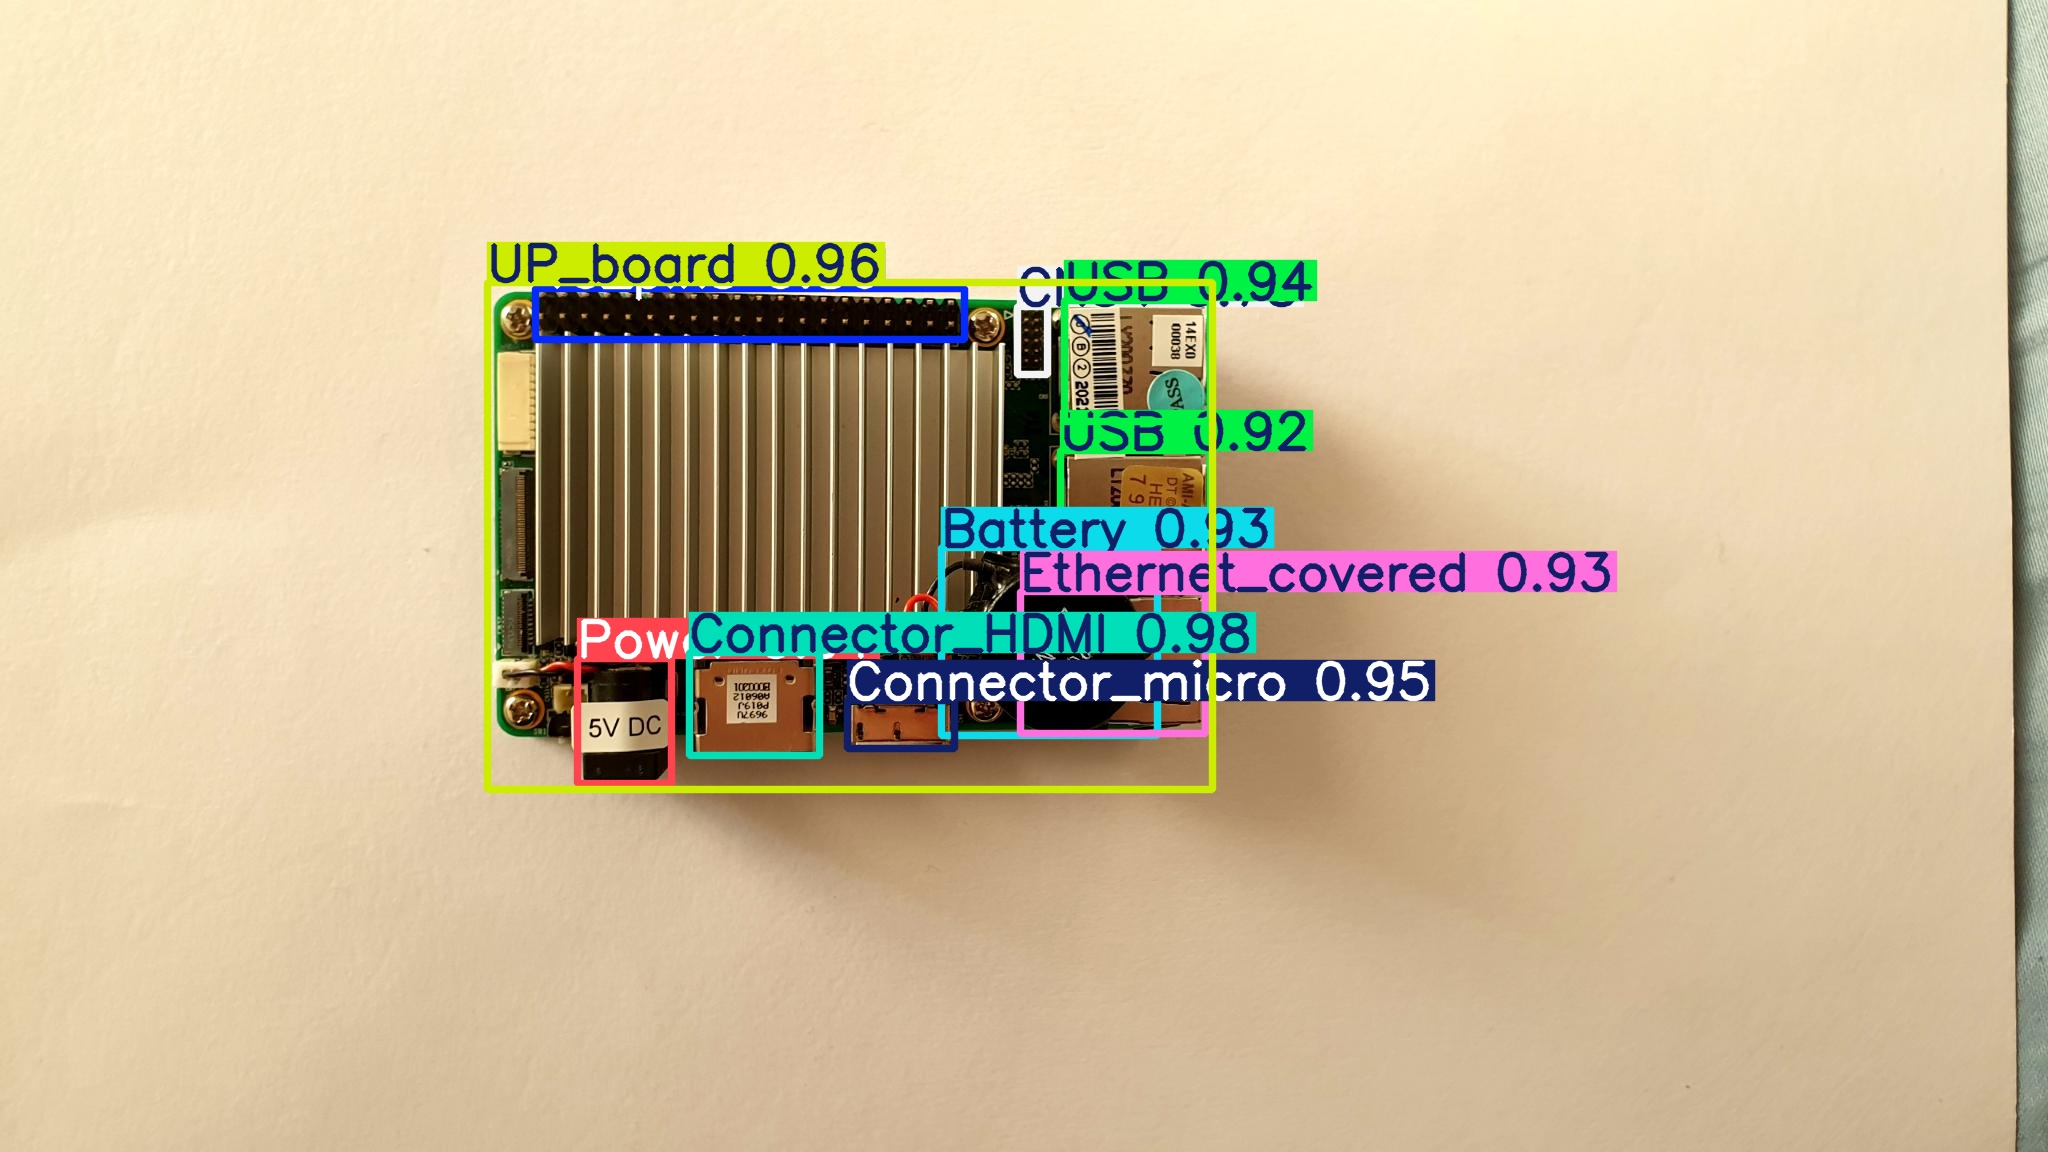

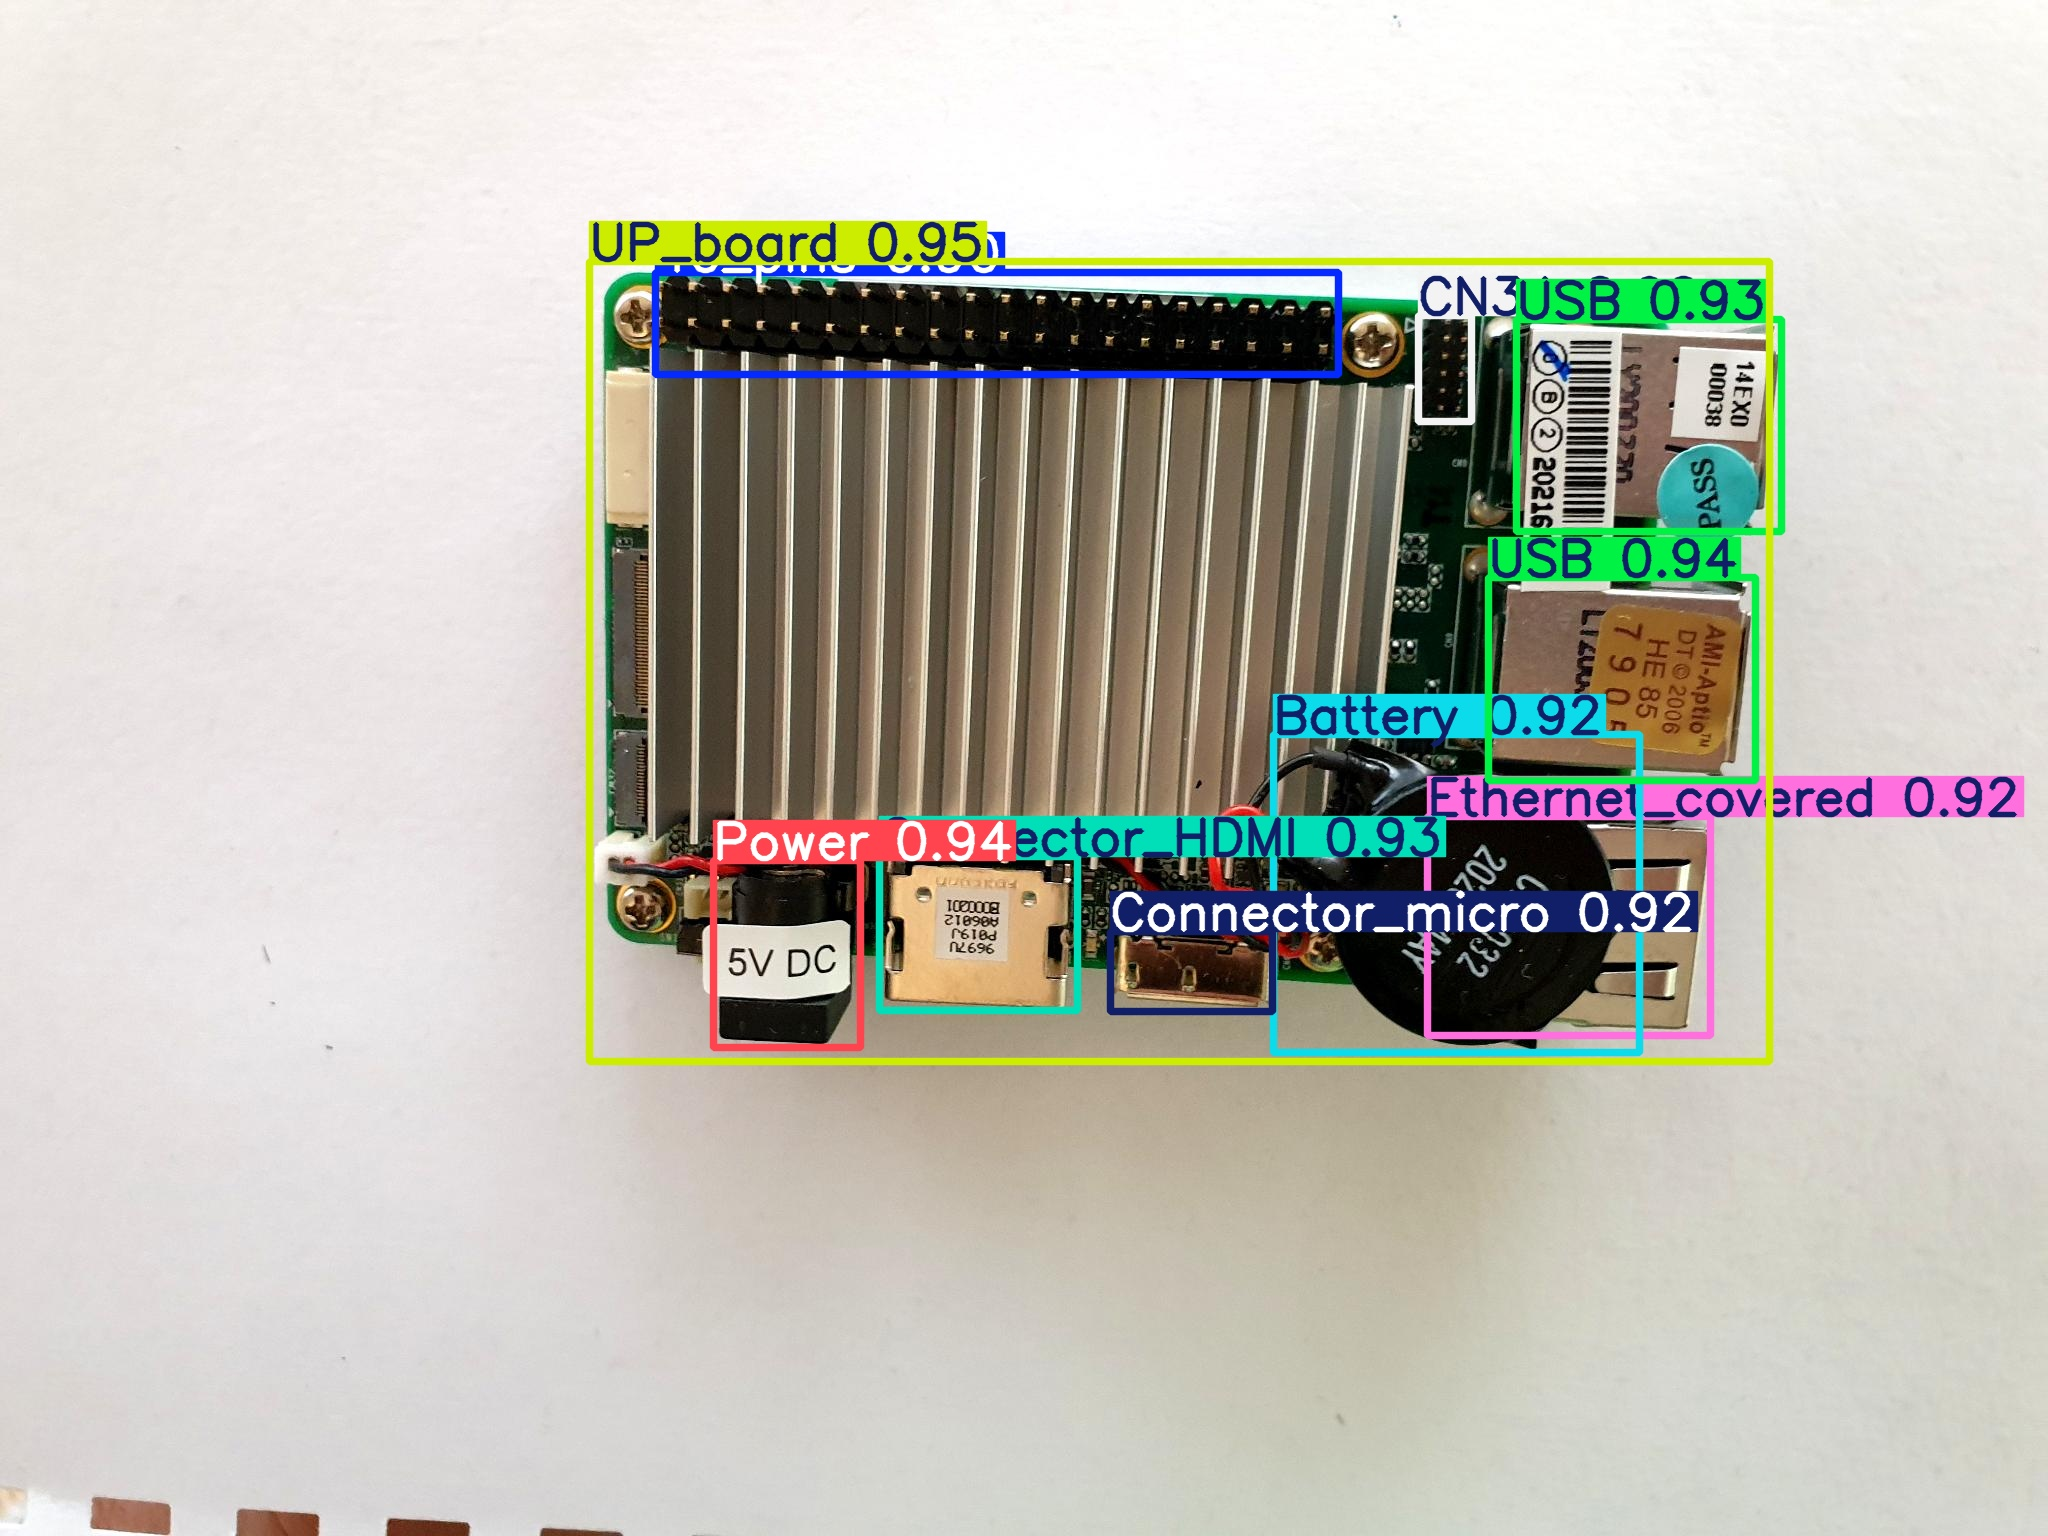

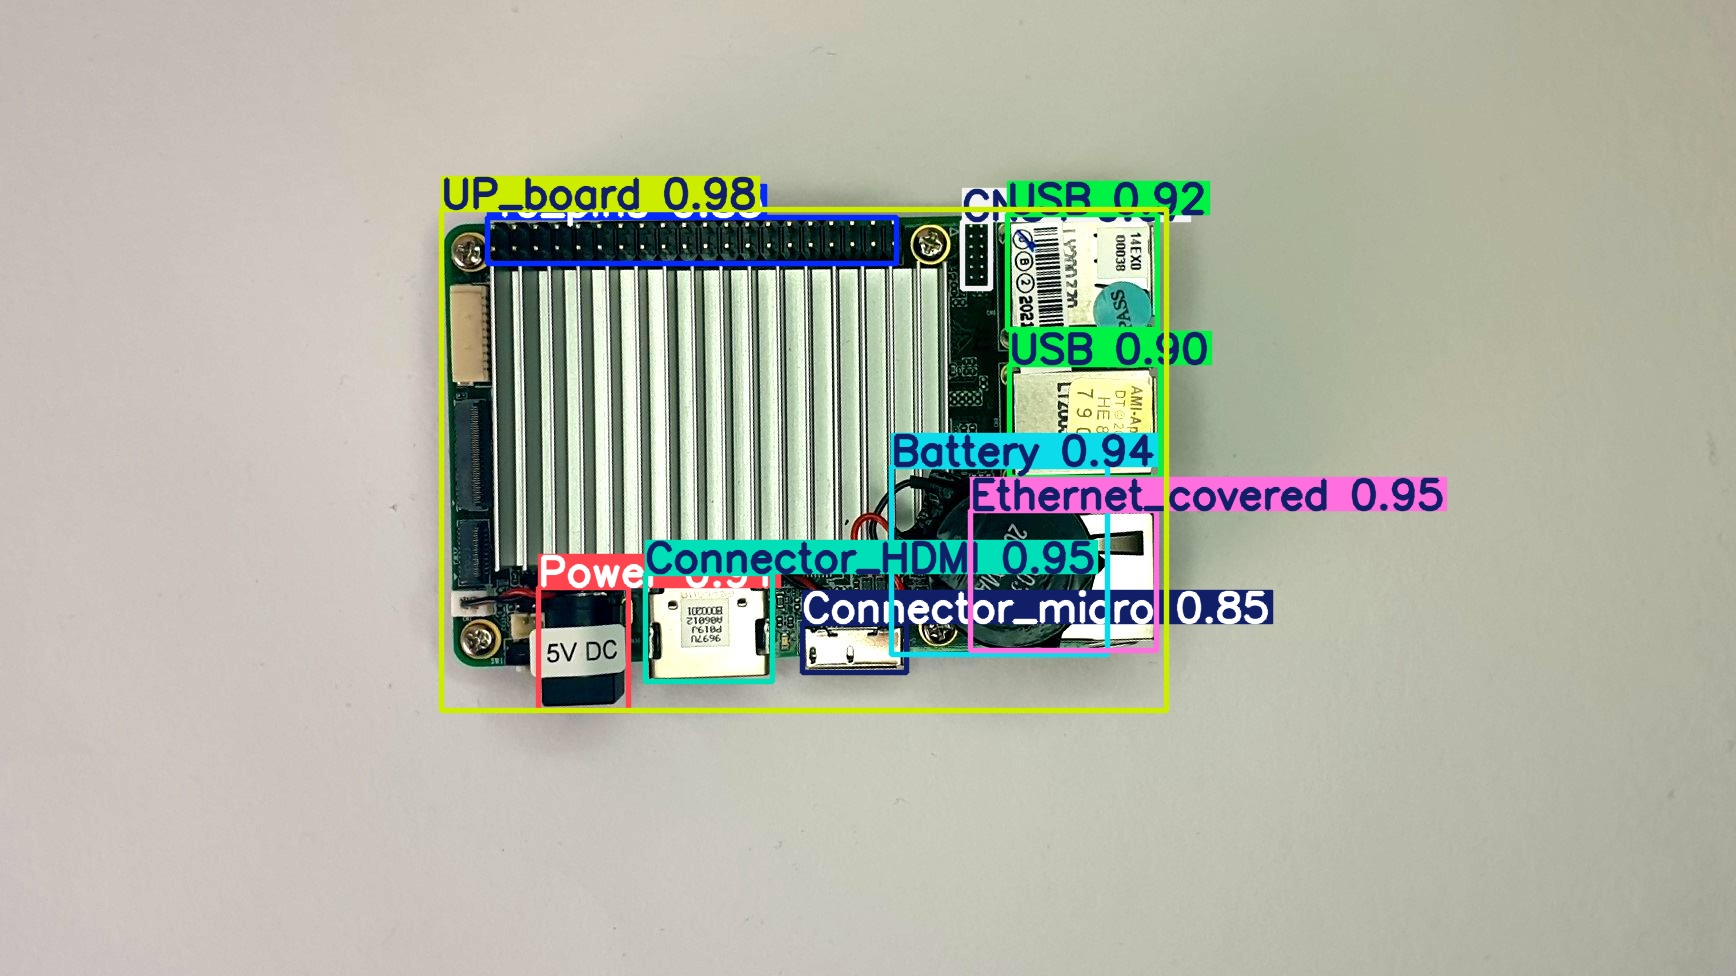

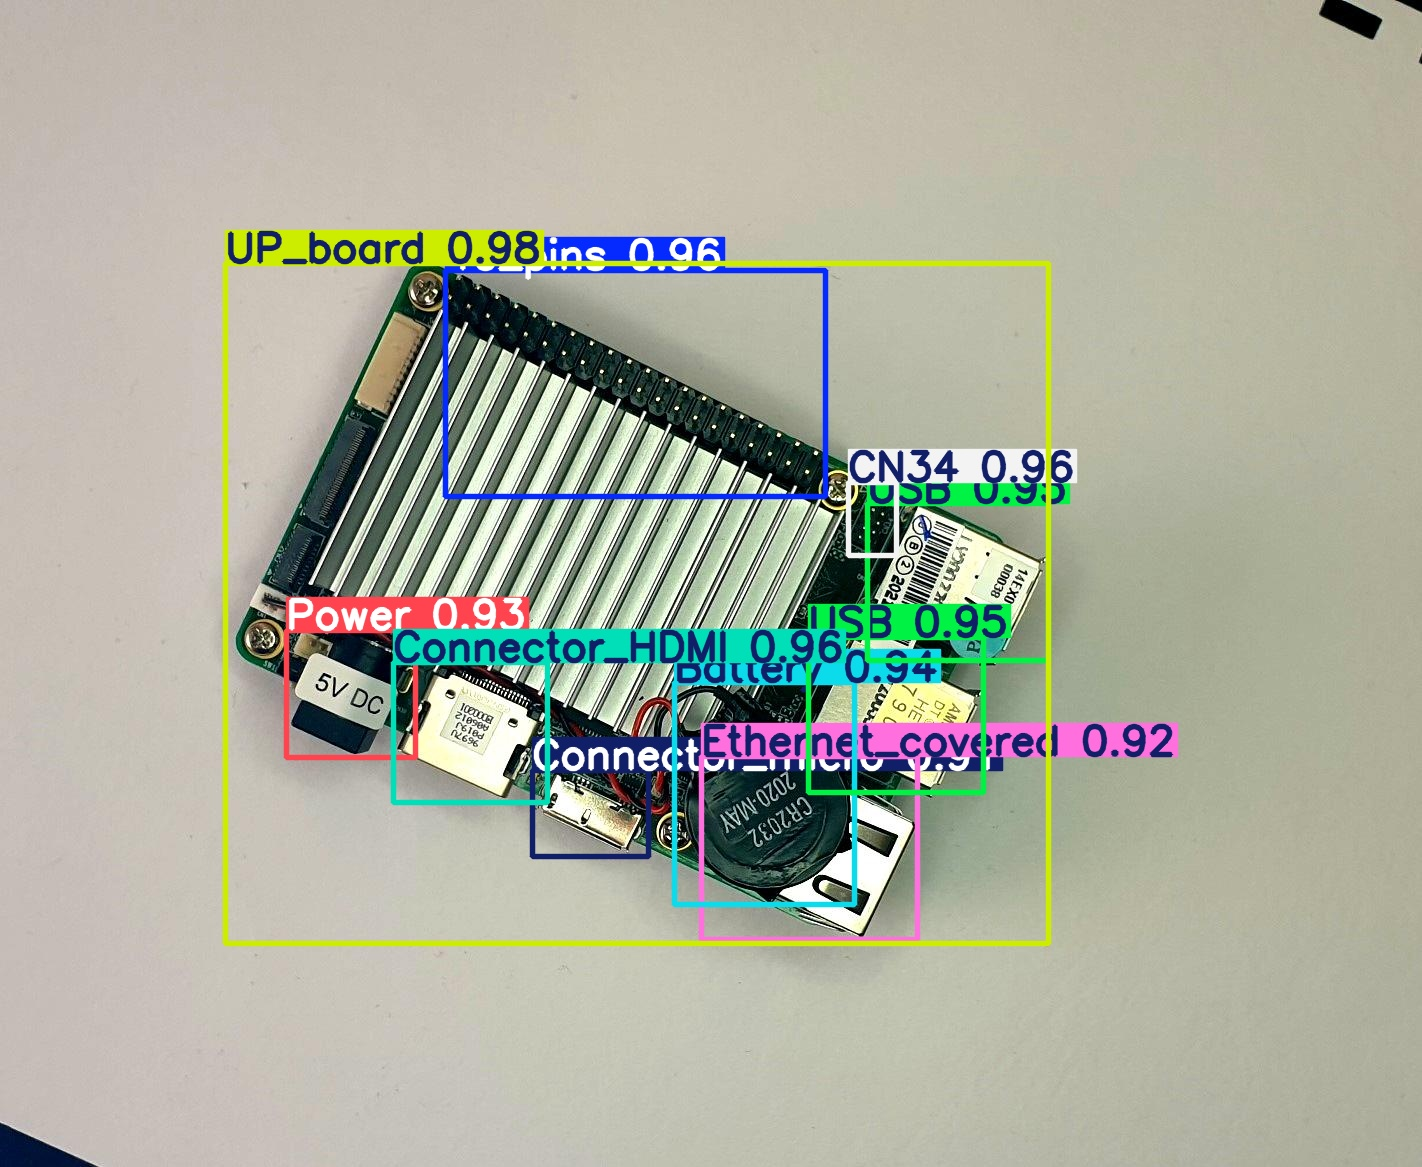

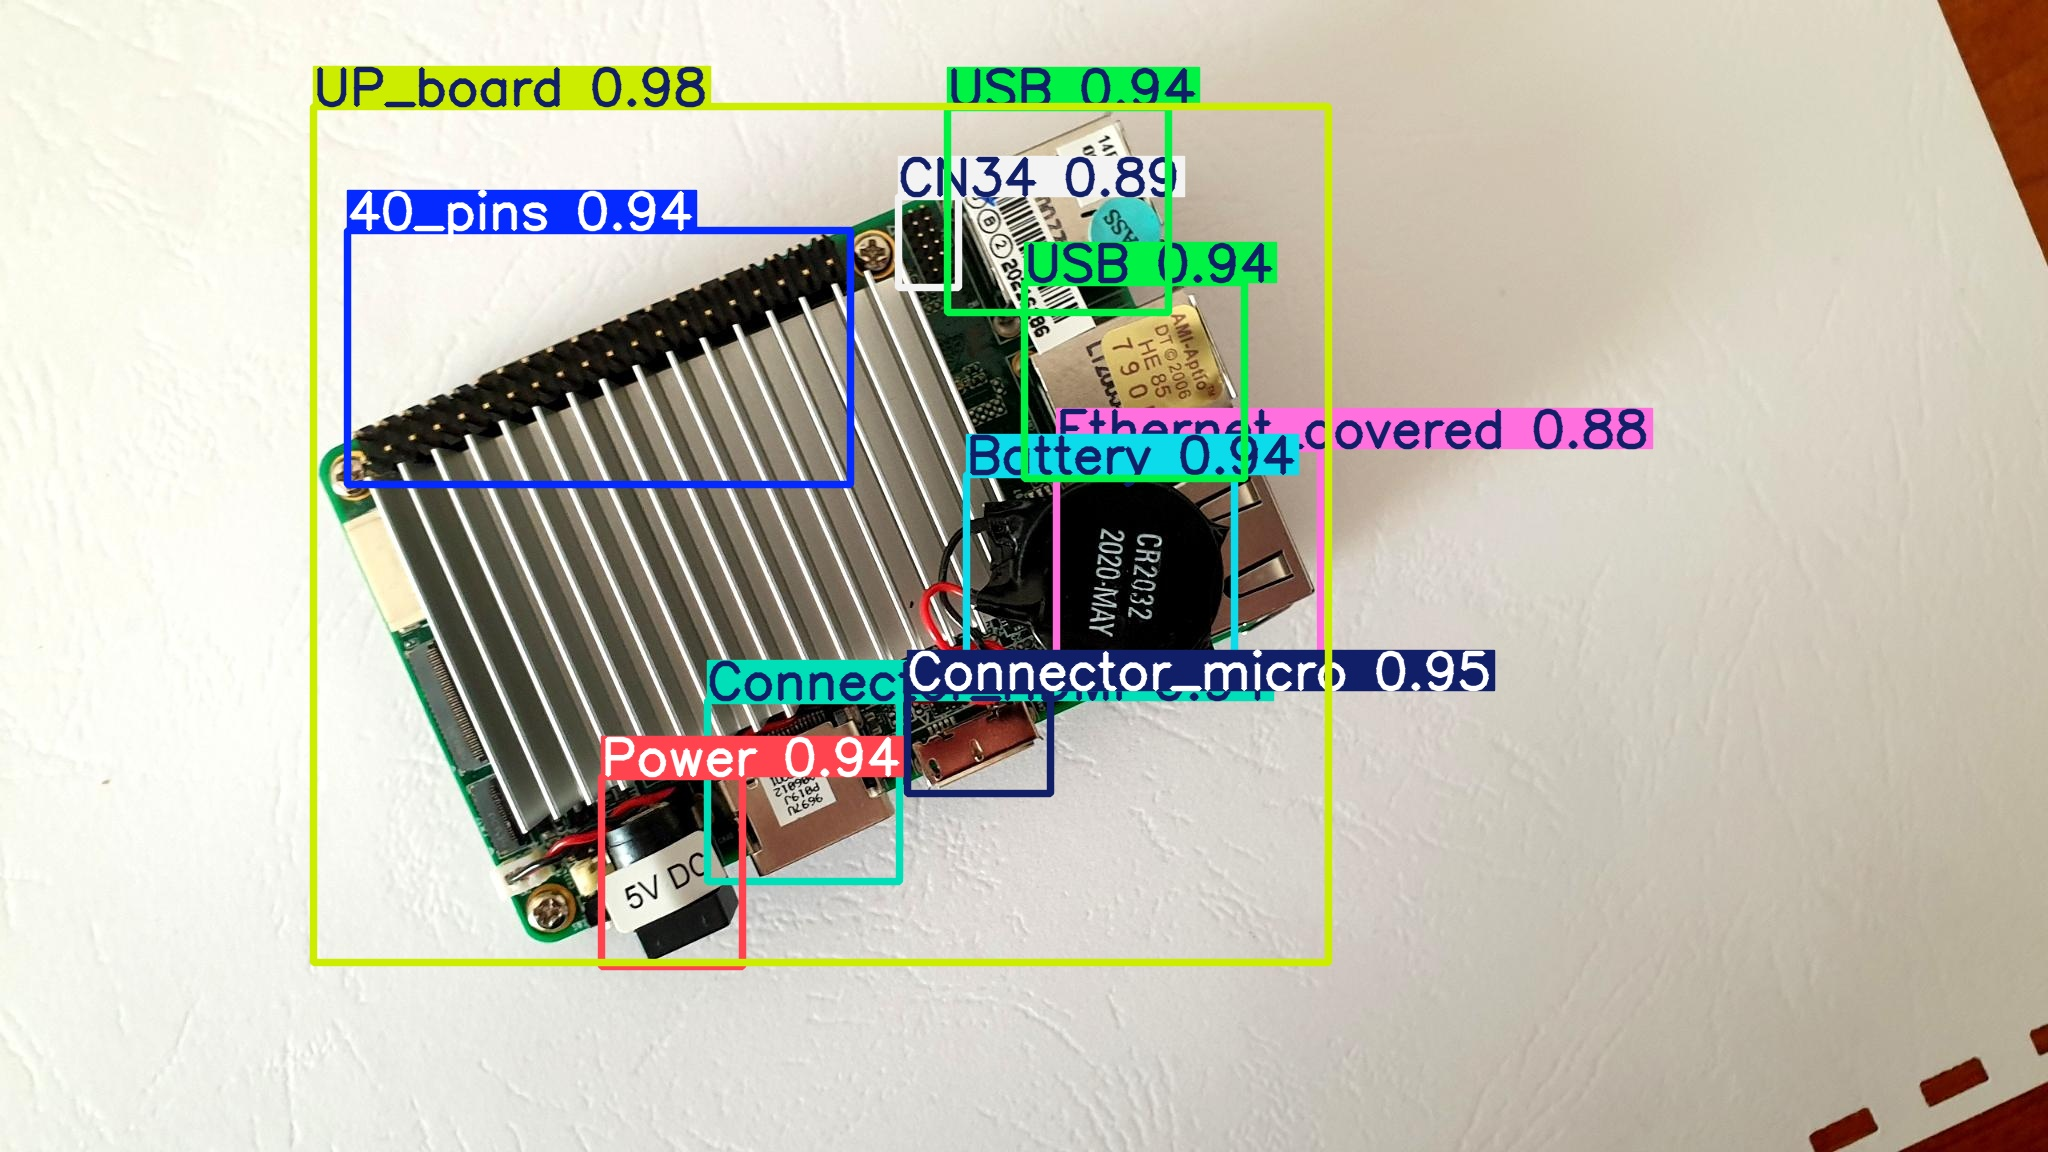

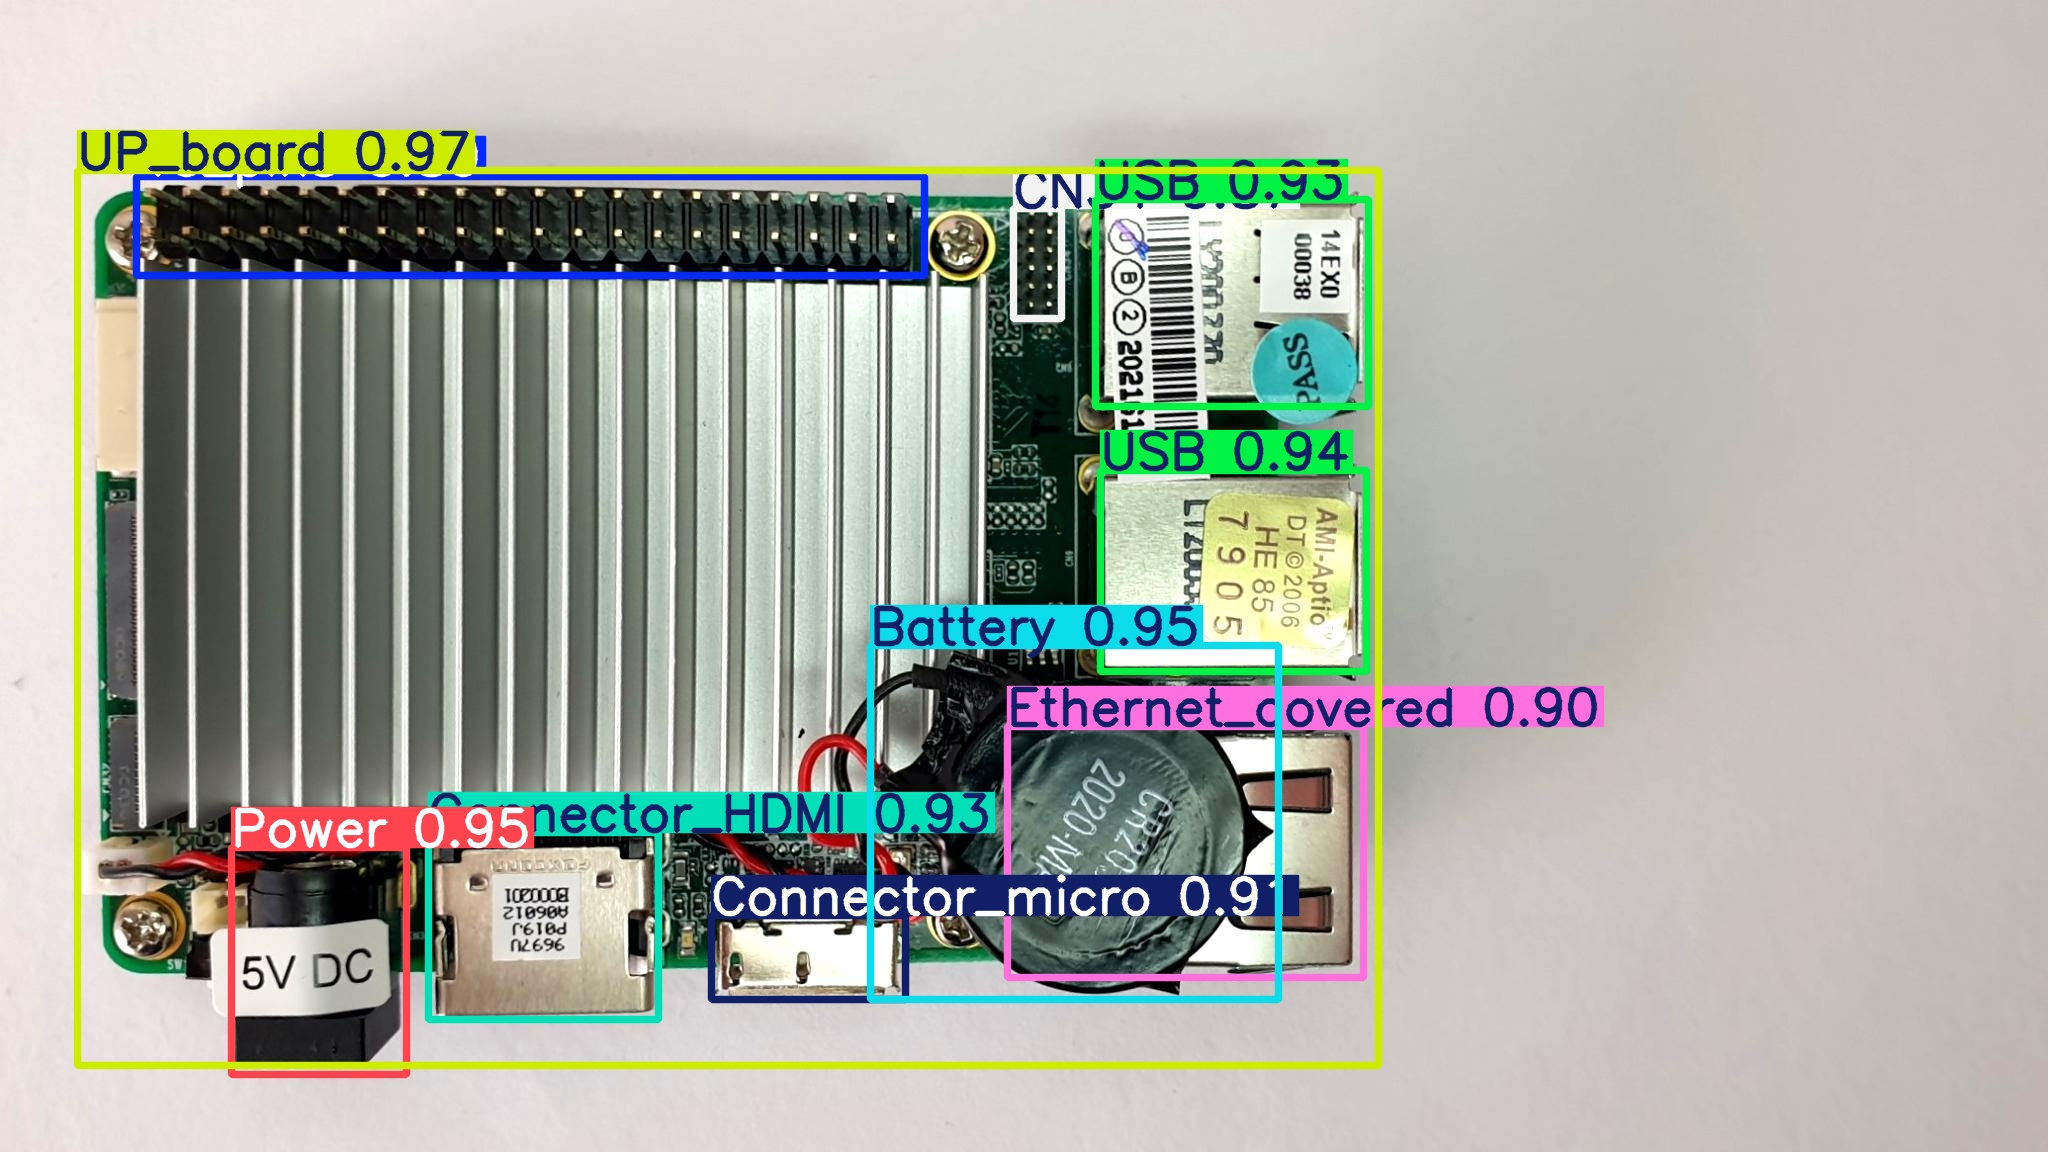

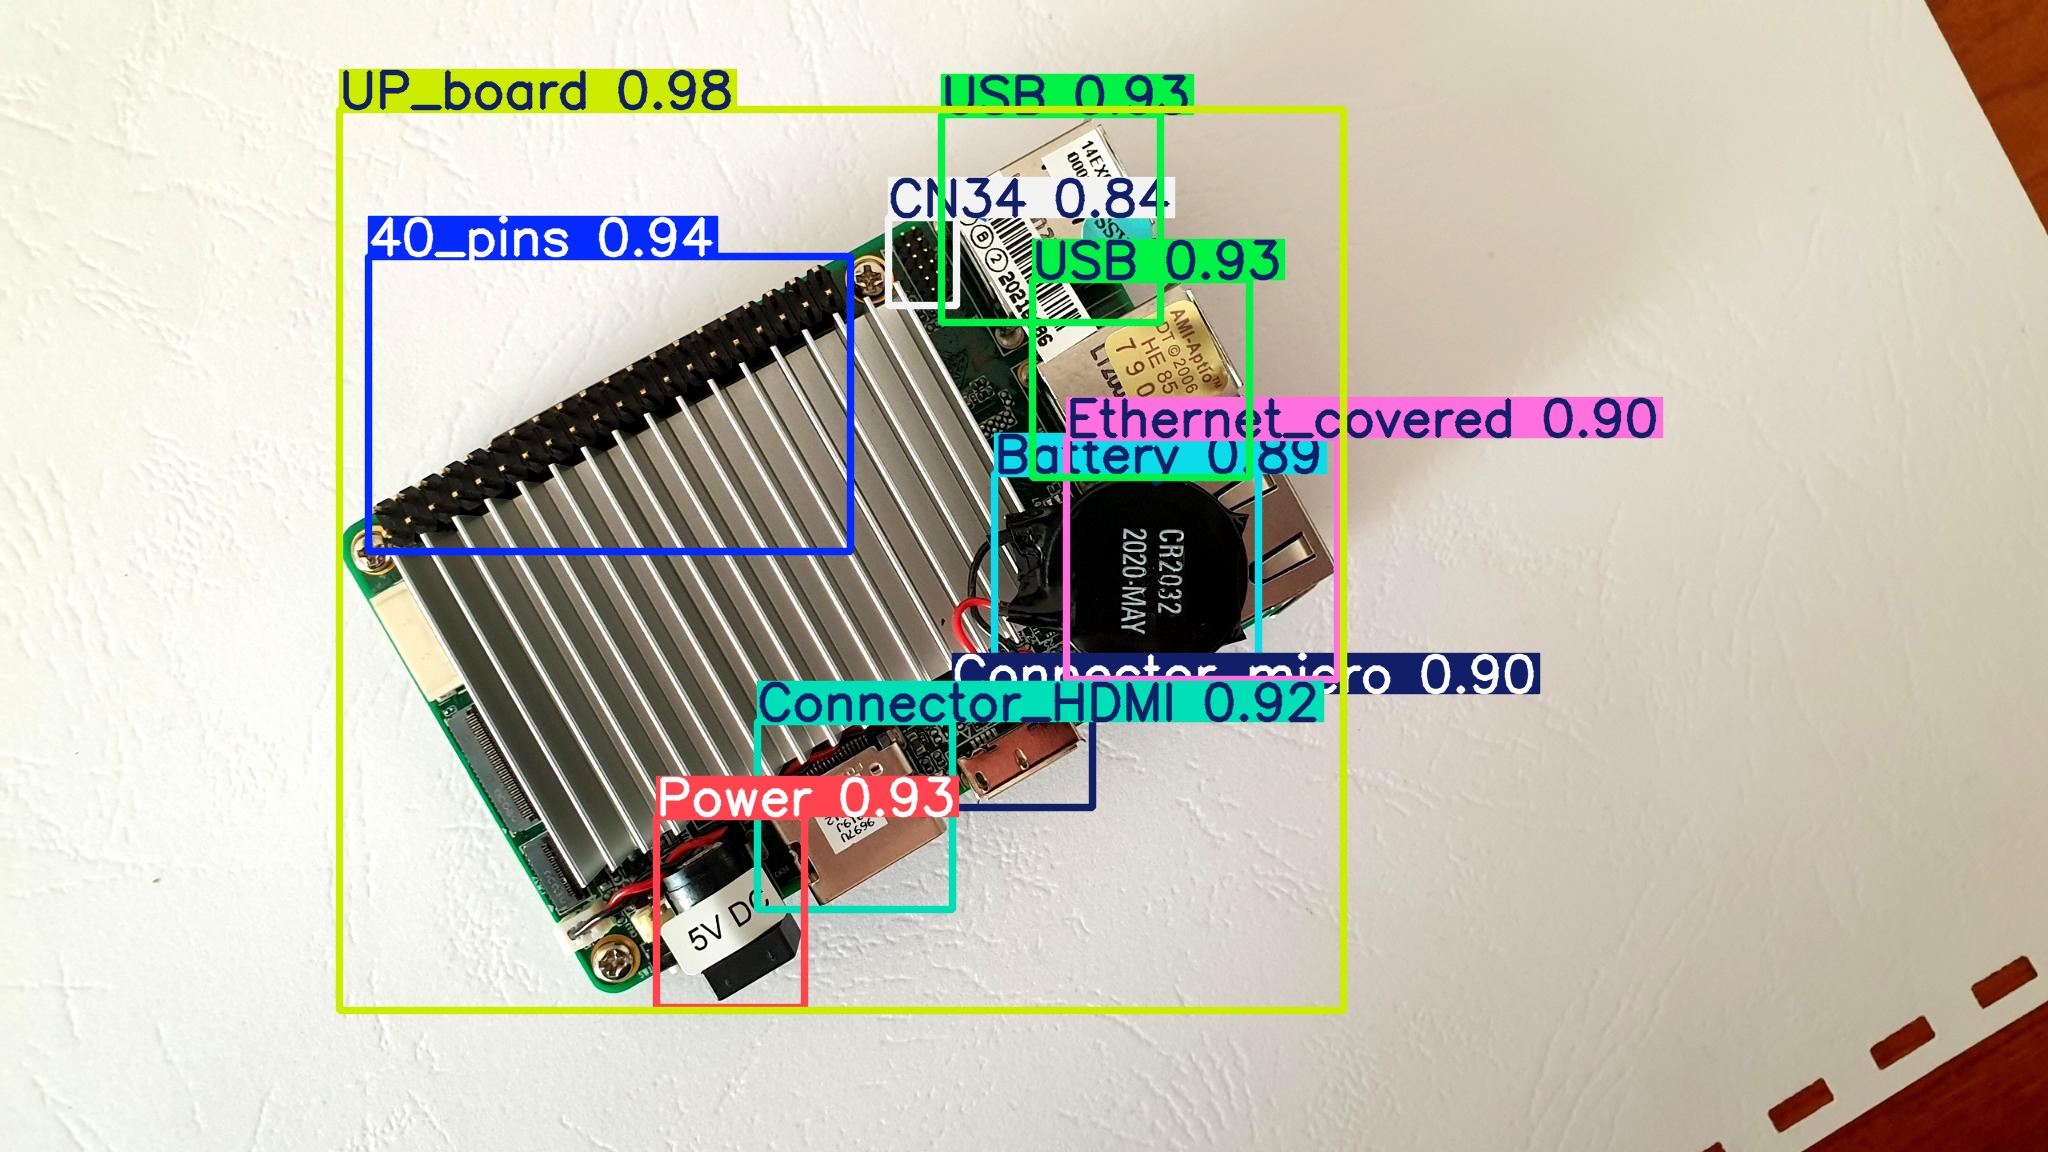

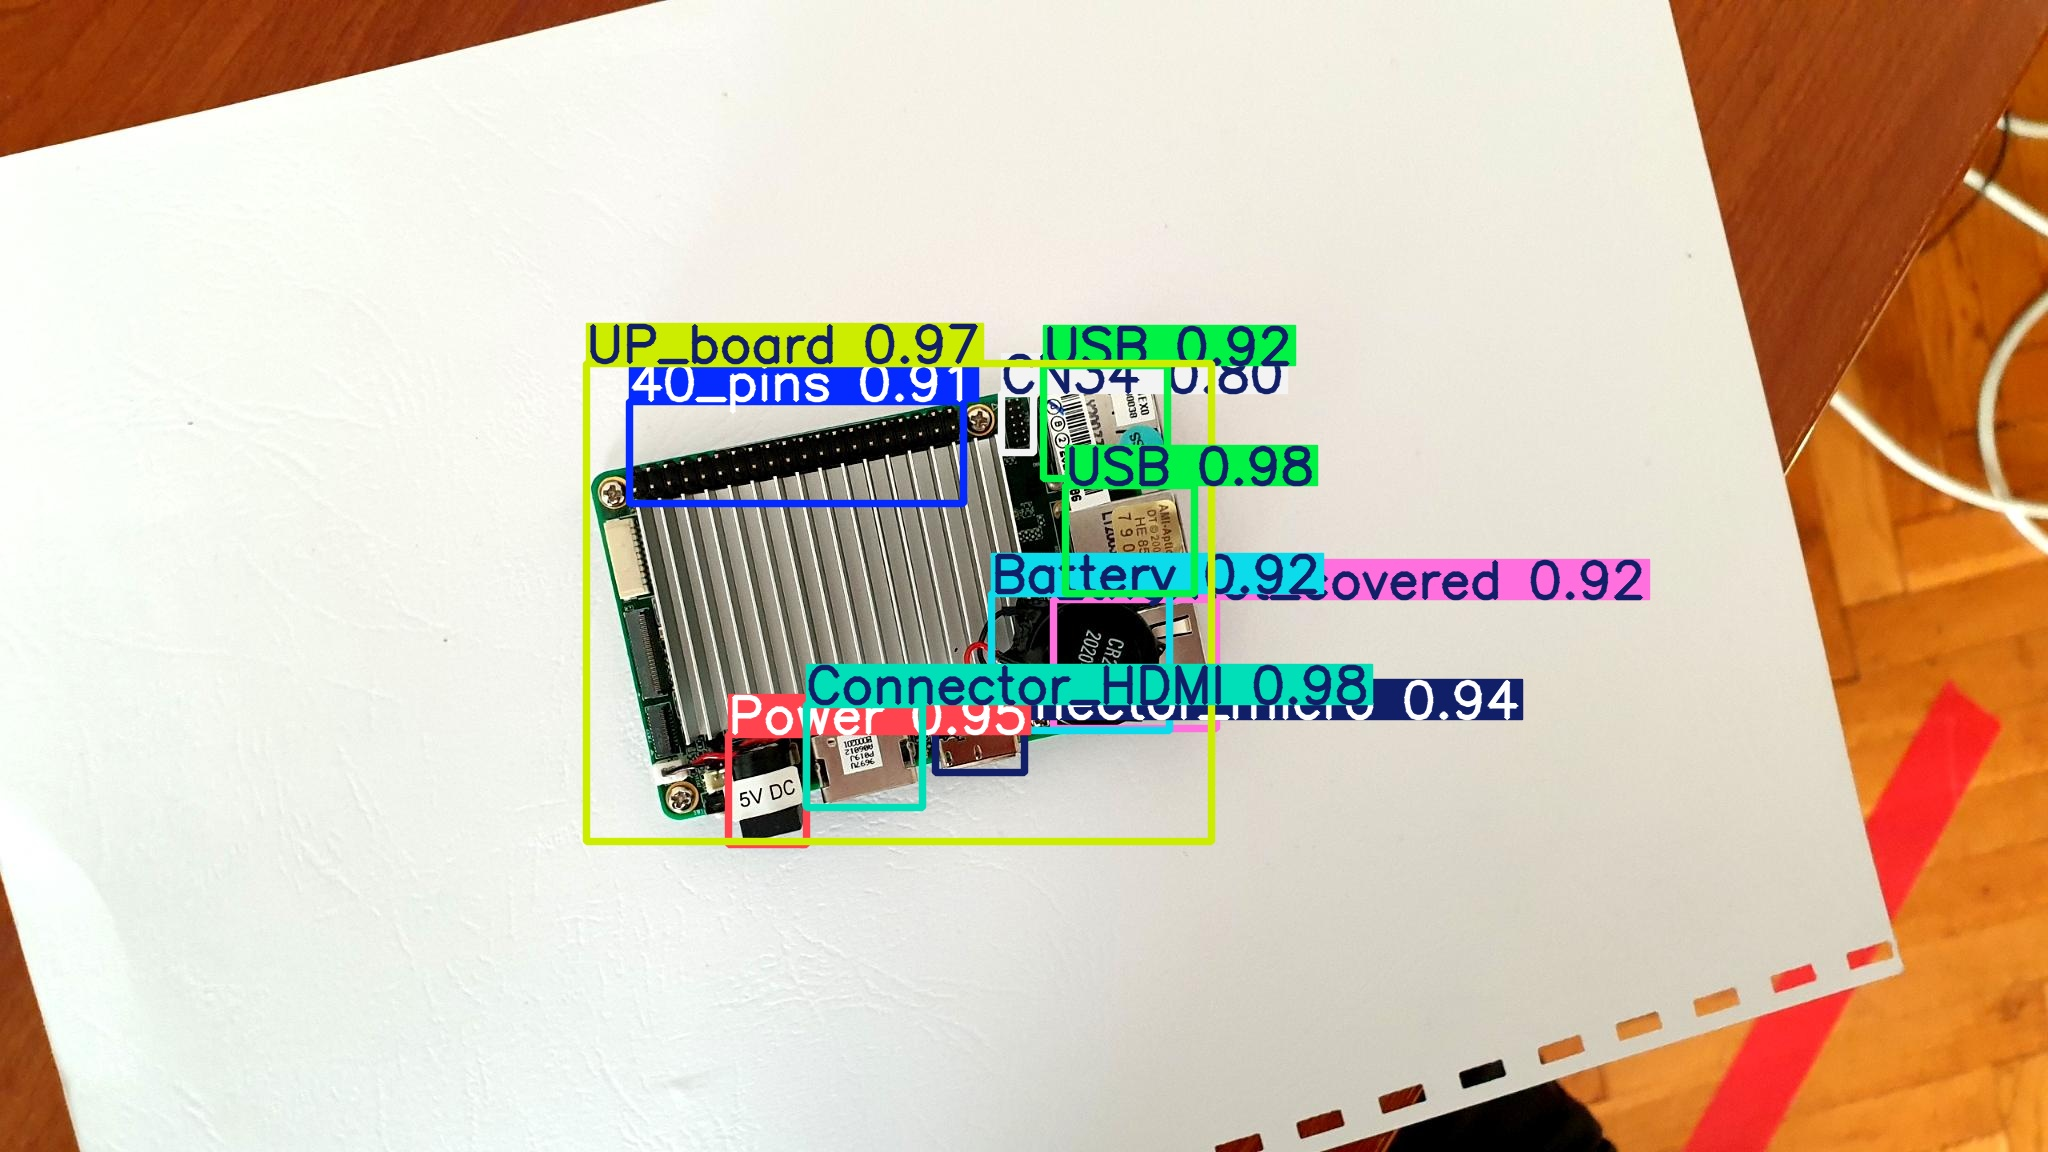

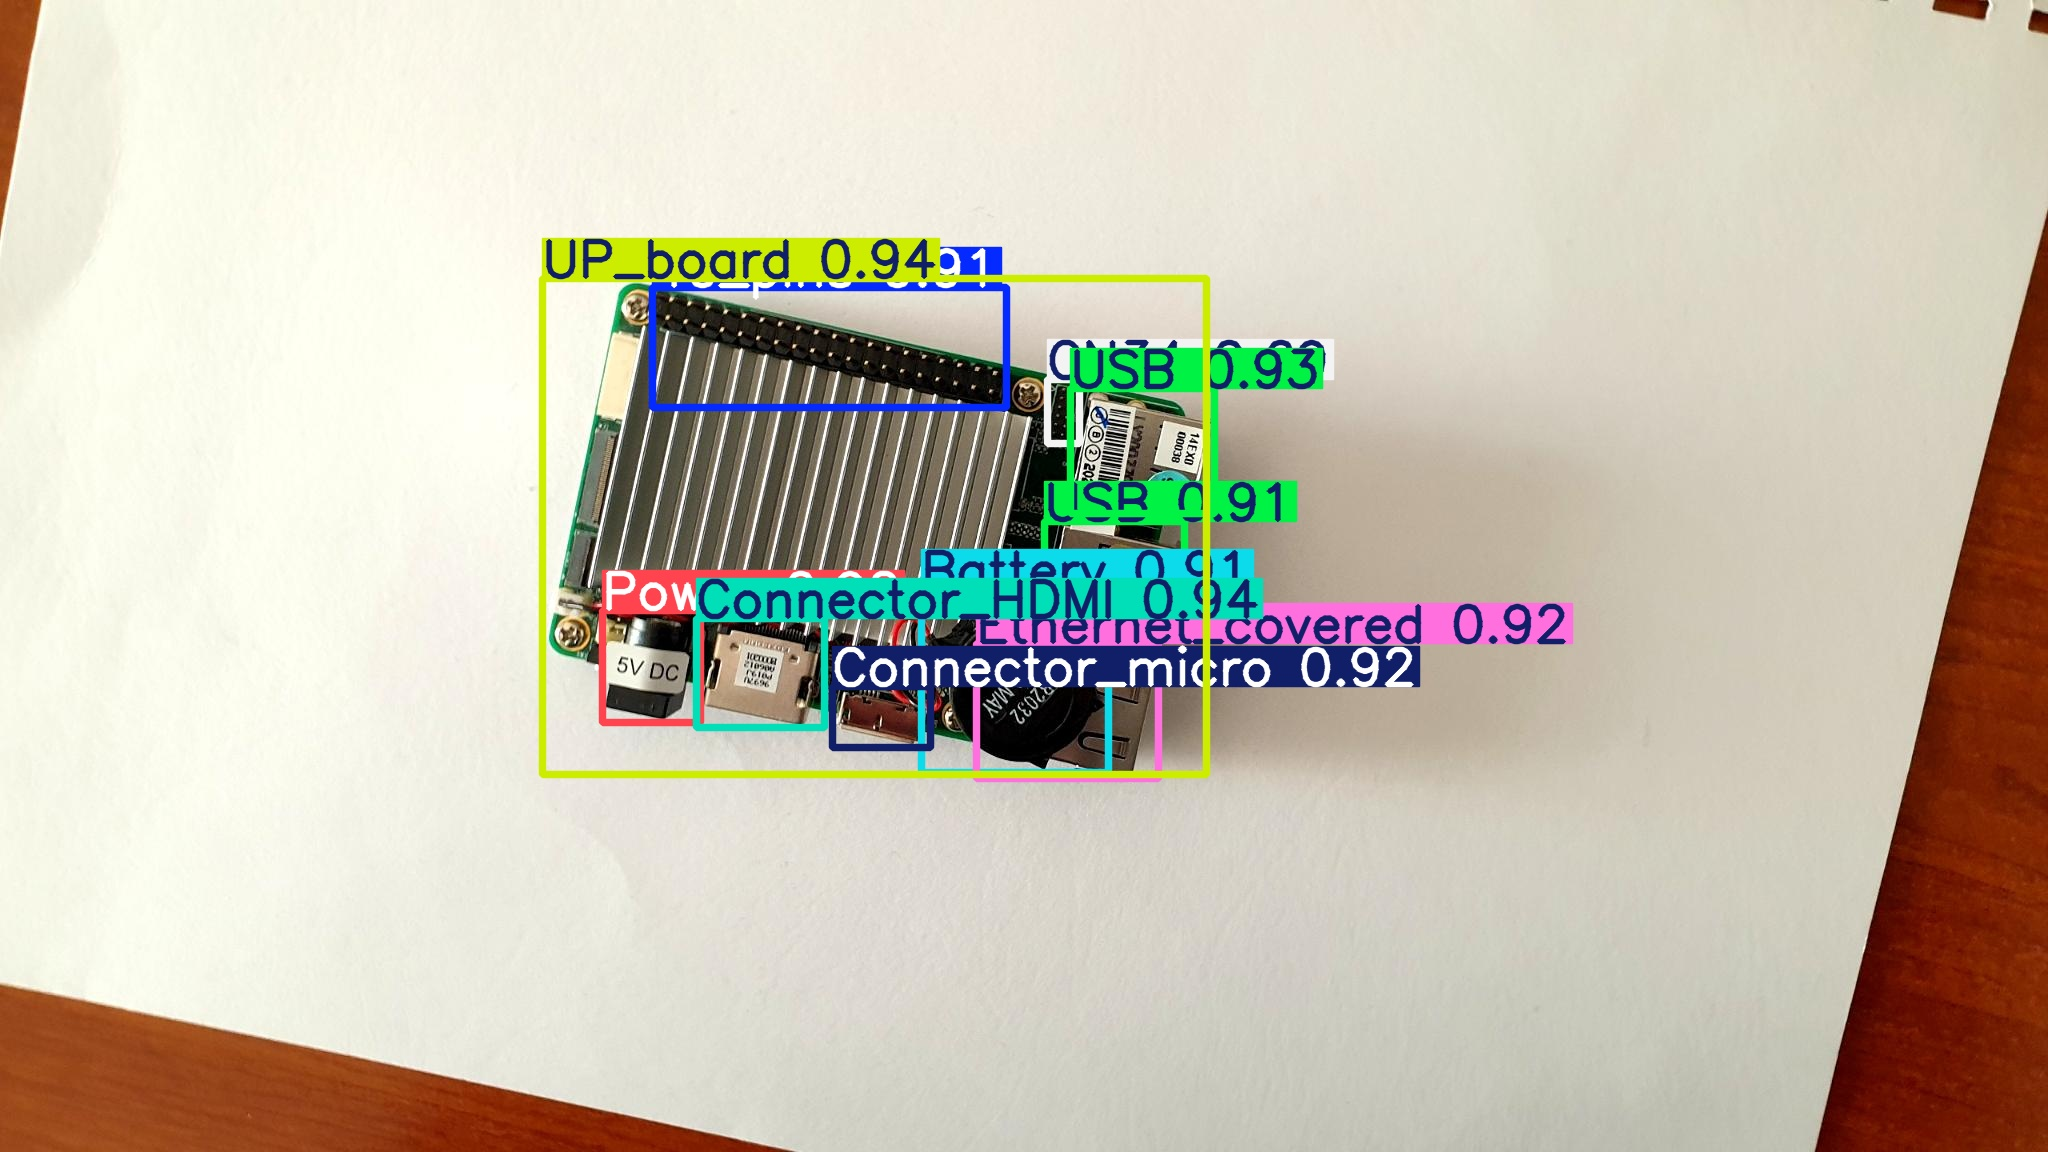

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:9]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=1000))
    print("\n")

In [ ]:
# Initialize the YOLO model
model = YOLO("yolov8m.pt")  # Ensure the task aligns with the model type

# Train the model
model.train(
    data={dataset.location}/data.yaml,  # Path to the dataset YAML
    epochs=100,           # Number of training epmhs
    imgsz=640,           # Image size
    batch=16,             # Batch size
    patience=10,         # Early stopping patience
    plots=True,           # Save training plots
    lr0=0.0001,            # Initial learning rate
    optimizer="AdamW"      # Use AdamW for small datasets and keypoints
)

100%|██████████| 49.7M/49.7M [00:00<00:00, 334MB/s]


NameError: name 'data' is not defined